<a href="https://colab.research.google.com/github/GeraldL19/Final-Year-Project-2024/blob/main/DAX_trial_23_10_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [16]:
df = pd.read_csv('esg_documents_for_dax_companies.csv', delimiter = '|', index_col = 0)

In [17]:
df

,company,content,datatype,date,domain,esg_topics,internal,symbol,title,url
2,Beiersdorf AG,Sustainability Highlight Report CARE BEYOND SK...,sustainability_report,2021-03-31,NaN,"['CleanWater', 'GHGEmission', 'ProductLiabilit...",1,BEI,BeiersdorfAG Sustainability Report 2021,NaN
3,Deutsche Telekom AG,Corporate Responsibility Report 2021 2 Content...,sustainability_report,2021-03-31,NaN,"['DataSecurity', 'Iso50001', 'GlobalWarming', ...",1,DTE,DeutscheTelekomAG Sustainability Report 2021,NaN
5,Vonovia SE,VONOVIA SE SUSTAINABILITY REPORT 2021 =For a S...,sustainability_report,2021-03-31,NaN,"['Whistleblowing', 'DataSecurity', 'Vaccine', ...",1,VNA,VonoviaSE Sustainability Report 2021,NaN
6,Merck KGaA,Sustainability Report 2021 TABLE OF CONTENTS S...,sustainability_report,2021-03-31,NaN,"['DataSecurity', 'DataMisuse', 'DrugResistance...",1,MRK,MerckKGaA Sustainability Report 2021,NaN
9,MTU,Our ideas and concepts FOR A SUSTAINABLE FUTUR...,sustainability_report,2020-03-31,NaN,"['WorkLifeBalance', 'Corruption', 'AirQuality'...",1,MTX,MTUAeroEngines Sustainability Report 2020,NaN
...,...,...,...,...,...,...,...,...,...,...
11451,Zalando SE,"To reset your pass, please enter your email be...",tech,2021-07-12,pocketgamer,"['CustomerService', 'Meat', 'HumanCapital', 'T...",0,ZAL,Pocket Gamer Connects Digital # 7,https://www.pocketgamer.biz/events/1636/pocket...
11452,Zalando SE,Lo esencial: Materias primas: correlaciones e...,business,2022-07-05,marketscreener,['WasteManagement'],0,ZAL,"Índices: ni Value ni Growth, ¡defensivos!",https://es.marketscreener.com/noticias/ultimas...
11453,Zalando SE,A look at the evolution of the fashion industr...,thinktank,2021-05-11,cbinsights,"['CustomerService', 'Recruiting', 'Sustainable...",0,ZAL,The Future of Fashion: Technology & the Industry,https://www.cbinsights.com/research/fashion-te...
11454,Zalando SE,"By clicking submit, you agree to share your em...",tech,2022-05-23,techfundingnews,"['ClimateTech', 'Cybersecurity', 'CorporateCul...",0,ZAL,These are the top 10 EMEA VCs of 2022 — TFN,https://techfundingnews.com/these-are-the-top-...


In [4]:
unique_sentiments = df.datatype.unique()
unique_sentiments

array(['sustainability_report', 'annual_report', 'tech', 'general',
       'business', 'esg', nan, 'thinktank', 'science', 'company_website'],
      dtype=object)

<Axes: >

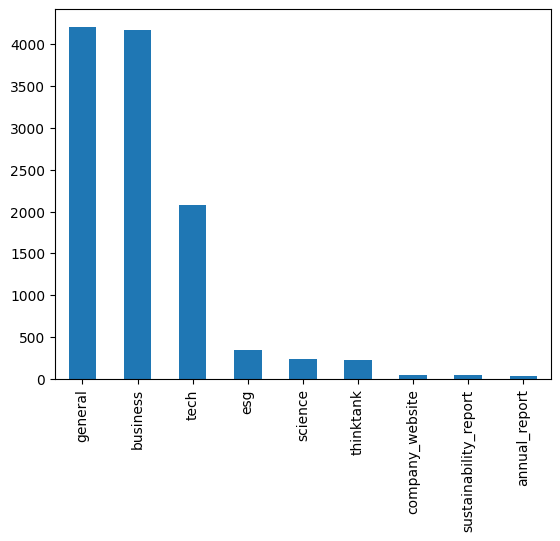

In [5]:
df.datatype.value_counts().plot.bar()

In [6]:
df.iloc[11452,1]

'For consumer goods companies in Europe, e-commerce has gone from a growth opportunity to an imperative. Success rests on an organization’ s ability to push beyond traditional approaches and innovate. Over the past two years, more-advanced players in mature categories ( such as fashion and accessories, beauty, consumer durables, and toys) have increasingly explored new formats ( such as live commerce and social commerce). At the same time, players in nascent categories, namely food and fastmoving consumer goods ( FMCG), started to develop a winning online-first playbook. This article is a collaborative effort by Isabel Cordoba, Carly Donovan, Max Magni, Jessica Moulton, and Samantha Phillips, representing views from McKinsey’ s Consumer Packaged Goods Practice. In the years ahead, fully unlocking growth in e-commerce will be just as critical. Although offline commerce has begun to bounce back, online channels have enjoyed markedly higher growth in recent years: mature categories grew a

In [7]:
import pandas as pd
import numpy as np
import matplotlib as plt
import re

In [18]:
df['esg_topics'] = df['esg_topics'].str.replace("[", "")
df['esg_topics'] = df['esg_topics'].str.replace("]", "")

<ipython-input-18-c7fe88e4783f>:1: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  df['esg_topics'] = df['esg_topics'].str.replace("[", "")
<ipython-input-18-c7fe88e4783f>:2: FutureWarning: The default value of regex will change from True to False in a future version. In addition, single character regular expressions will *not* be treated as literal strings when regex=True.
  df['esg_topics'] = df['esg_topics'].str.replace("]", "")


In [19]:
df.esg_topics.str.split(',', expand=True).stack().value_counts().head(50)

 'Social'               1791
 'Environment'          1493
 'Transparency'         1014
 'HumanCapital'          953
'Privacy'                881
 'GenderDiversity'       753
'Social'                 728
 'CarbonDioxide'         725
'RenewableEnergy'        724
 'GHGEmission'           714
 'LowCarbon'             710
 'RenewableEnergy'       698
 'RussianFederation'     696
 'ClimateChange'         645
 'EMobility'             626
                         615
'EMobility'              574
 'Compliance'            547
'Environment'            528
 'NaturalGas'            522
 'Recruiting'            512
'GenderDiversity'        508
 'CorporateCulture'      476
 'FossilFuels'           472
 'Recycling'             467
 'Vaccine'               465
 'Governance'            414
'HumanCapital'           376
 'Coal'                  376
 'ValueChain'            374
'ValueChain'             373
'RussianFederation'      370
 'Sanction'              368
'Compliance'             335
 'Privacy'    